[Parallel(n_jobs=-1)]: Using backend LokyBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of 961 | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done  23 out of 961 | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  40 out of 961 | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done  59 out of 961 | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done  78 out of 961 | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done  99 out of 961 | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done 120 out of 961 | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 143 out of 961 | elapsed:   22.1s
[Parallel(n_jobs=-1)]: Done 166 out of 961 | elapsed:   27.0s
[Parallel(n_jobs=-1)]: Done 191 out of 961 | elapsed:   31.7s
[Parallel(n_jobs=-1)]: Done 216 out of 961 | elapsed:   36.4s
[Parallel(n_jobs=-1)]: Done 243 out of 961 | elapsed:   40.9s
[Parallel(n_jobs=-1)]: Done 270 out of 961 | elapsed:   45.2s
[Parallel(n_jobs=-1)]: Done 299 out of 961 | elapsed:   51.6s
[Parallel(n_jobs=-1)]: Done 328 out of 961 | elapsed:  

Hardening mean threshold below Omega=1: 0.2933333333333333
Hardening mean threshold above Omega=1: 0.35999999999999993


[Parallel(n_jobs=-1)]: Done 961 out of 961 | elapsed:  3.9min finished


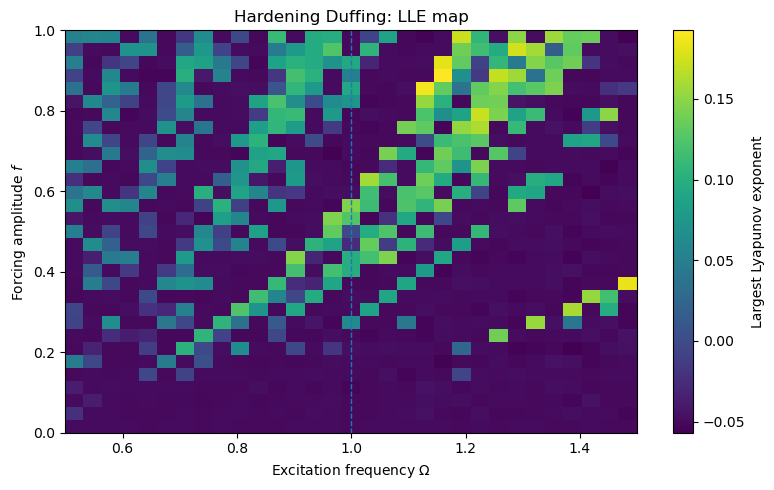

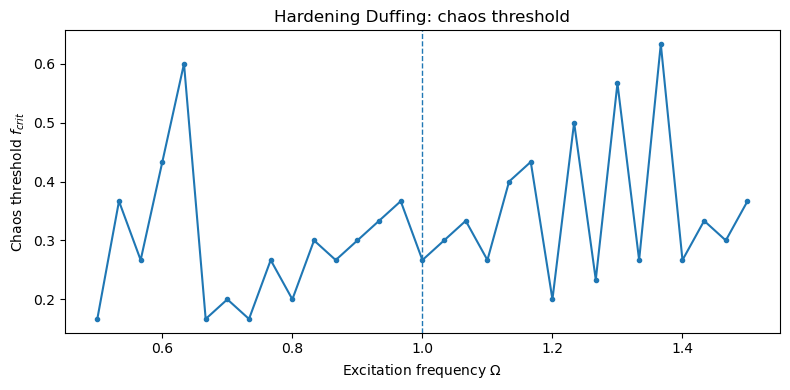

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18911075592041016s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   6 out of 961 | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  23 out of 961 | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  40 out of 961 | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  59 out of 961 | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  78 out of 961 | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 107 out of 961 | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 149 out of 961 | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 195 out of 961 | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 241 out of 961 | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 291 out of 961 | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 341 out of 961 | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 395 out of 961 | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 448 out of 961 | elapsed:    2.1s
[Parallel(n_jobs=-1)]

Softening mean threshold below Omega=1: nan
Softening mean threshold above Omega=1: nan


[Parallel(n_jobs=-1)]: Done 937 out of 961 | elapsed:    3.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 961 out of 961 | elapsed:    3.3s finished


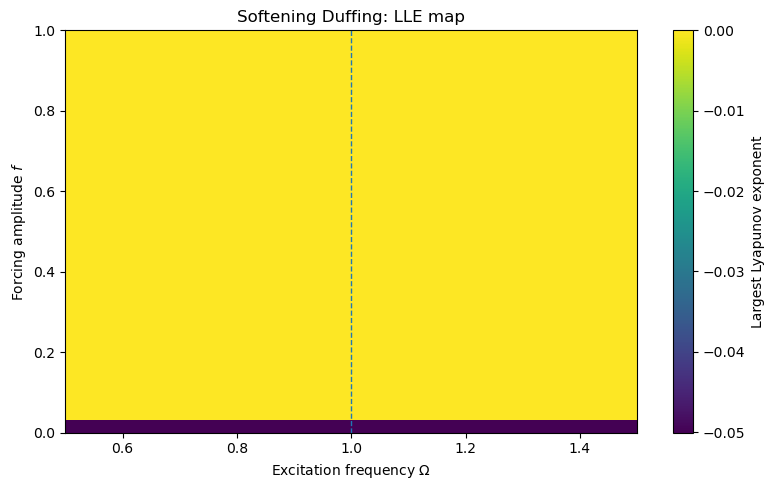

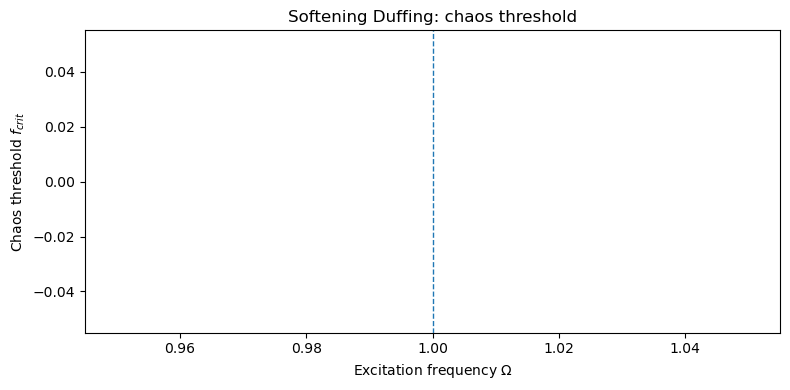

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from dataclasses import dataclass
from joblib import Parallel, delayed


@dataclass
class DuffingParams:
	zeta: float = 0.05
	beta: float = 1.0
	omega: float = 1.0
	forcing: float = 0.2


@dataclass
class SimulationParams:
	n_transient: int = 500
	n_sample: int = 200
	points_per_period: int = 100
	rtol: float = 1e-9
	atol: float = 1e-11
	lyapunov_threshold: float = 1e-3


def duffing_rhs(t, y, params):
	x, v = y
	zeta = params.zeta
	beta = params.beta
	Omega = params.omega
	f = params.forcing

	dxdt = v
	dvdt = -2.0 * zeta * v - x - beta * x**3 + f * np.cos(Omega * t)

	return np.array([dxdt, dvdt])


def duffing_variational_rhs(t, y_aug, params):
	x = y_aug[0]
	v = y_aug[1]
	w = y_aug[2:4]

	zeta = params.zeta
	beta = params.beta
	Omega = params.omega
	f = params.forcing

	dxdt = v
	dvdt = -2.0 * zeta * v - x - beta * x**3 + f * np.cos(Omega * t)

	A = np.array([
		[0.0, 1.0],
		[-1.0 - 3.0 * beta * x**2, -2.0 * zeta]
	])

	dwdt = A @ w

	return np.concatenate(([dxdt, dvdt], dwdt))


def integrate_duffing(params, sim, z0):
	T = 2.0 * np.pi / params.omega
	t_end = (sim.n_transient + sim.n_sample) * T
	max_step = T / sim.points_per_period

	sol = solve_ivp(
		lambda t, y: duffing_rhs(t, y, params),
		(0.0, t_end),
		z0,
		rtol=sim.rtol,
		atol=sim.atol,
		max_step=max_step,
		dense_output=True
	)

	return sol


def poincare_points(params, sim, z0):
	T = 2.0 * np.pi / params.omega
	sol = integrate_duffing(params, sim, z0)

	sample_indices = np.arange(sim.n_transient, sim.n_transient + sim.n_sample + 1)
	t_sample = sample_indices * T
	z_sample = sol.sol(t_sample).T

	return z_sample, sol


def largest_lyapunov_exponent(params, sim, z0, perturbation_norm=1e-8):
	T = 2.0 * np.pi / params.omega
	max_step = T / sim.points_per_period

	z = np.array(z0, dtype=float)
	w = np.array([perturbation_norm, 0.0], dtype=float)

	log_sum = 0.0
	total_time = 0.0
	t0 = 0.0

	for k in range(sim.n_transient + sim.n_sample):
		y_aug0 = np.concatenate((z, w))

		sol = solve_ivp(
			lambda t, y: duffing_variational_rhs(t, y, params),
			(t0, t0 + T),
			y_aug0,
			rtol=sim.rtol,
			atol=sim.atol,
			max_step=max_step
		)

		z = sol.y[0:2, -1]
		w = sol.y[2:4, -1]

		w_norm = np.linalg.norm(w)

		if w_norm == 0.0 or not np.isfinite(w_norm):
			return np.nan

		if k >= sim.n_transient:
			log_sum += np.log(w_norm / perturbation_norm)
			total_time += T

		w = perturbation_norm * w / w_norm
		t0 += T

	return log_sum / total_time


def classify_from_lle(lle, threshold=1e-3):
	if not np.isfinite(lle):
		return -1
	if lle > threshold:
		return 1
	return 0


def compute_lle_grid_point(i, j, f, Omega, beta, zeta, z0, sim):
	params = DuffingParams(
		zeta=zeta,
		beta=beta,
		omega=Omega,
		forcing=f
	)

	lle = largest_lyapunov_exponent(params, sim, z0)
	class_id = classify_from_lle(lle, sim.lyapunov_threshold)

	return i, j, lle, class_id


def sweep_omega_forcing(beta=1.0, zeta=0.05, omega_values=None, forcing_values=None, z0=None, sim=None, n_jobs=-1, verbose=10):
	if omega_values is None:
		omega_values = np.linspace(0.5, 1.5, 41)

	if forcing_values is None:
		forcing_values = np.linspace(0.0, 1.0, 41)

	if z0 is None:
		z0 = np.array([0.0, 0.0])

	if sim is None:
		sim = SimulationParams(n_transient=300, n_sample=100, points_per_period=80)

	lle_map = np.full((len(forcing_values), len(omega_values)), np.nan)
	class_map = np.full((len(forcing_values), len(omega_values)), -1, dtype=int)

	jobs = [
		delayed(compute_lle_grid_point)(i, j, f, Omega, beta, zeta, z0, sim)
		for i, f in enumerate(forcing_values)
		for j, Omega in enumerate(omega_values)
	]

	results = Parallel(n_jobs=n_jobs, verbose=verbose)(jobs)

	for i, j, lle, class_id in results:
		lle_map[i, j] = lle
		class_map[i, j] = class_id

	return omega_values, forcing_values, lle_map, class_map


def extract_chaos_threshold(omega_values, forcing_values, lle_map, threshold=1e-3):
	f_crit = np.full(len(omega_values), np.nan)

	for j in range(len(omega_values)):
		chaotic_indices = np.where(lle_map[:, j] > threshold)[0]

		if len(chaotic_indices) > 0:
			f_crit[j] = forcing_values[chaotic_indices[0]]

	return f_crit


def plot_lle_map(omega_values, forcing_values, lle_map, title):
	plt.figure(figsize=(8, 5))
	plt.imshow(
		lle_map,
		origin="lower",
		aspect="auto",
		extent=[omega_values[0], omega_values[-1], forcing_values[0], forcing_values[-1]]
	)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.colorbar(label="Largest Lyapunov exponent")
	plt.xlabel(r"Excitation frequency $\Omega$")
	plt.ylabel(r"Forcing amplitude $f$")
	plt.title(title)
	plt.tight_layout()
	plt.show()


def plot_chaos_threshold(omega_values, f_crit, title):
	plt.figure(figsize=(8, 4))
	plt.plot(omega_values, f_crit, marker="o", markersize=3)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel(r"Excitation frequency $\Omega$")
	plt.ylabel(r"Chaos threshold $f_{crit}$")
	plt.title(title)
	plt.tight_layout()
	plt.show()


def plot_poincare_bifurcation(beta=1.0, zeta=0.05, forcing=0.4, omega_values=None, z0=None, sim=None):
	if omega_values is None:
		omega_values = np.linspace(0.5, 1.5, 200)

	if z0 is None:
		z0 = np.array([0.0, 0.0])

	if sim is None:
		sim = SimulationParams(n_transient=500, n_sample=100, points_per_period=100)

	all_omega = []
	all_x = []

	for Omega in omega_values:
		params = DuffingParams(
			zeta=zeta,
			beta=beta,
			omega=Omega,
			forcing=forcing
		)

		z_sample, _ = poincare_points(params, sim, z0)
		all_omega.extend([Omega] * len(z_sample))
		all_x.extend(z_sample[:, 0])

		z0 = z_sample[-1]

		print(f"Poincare done: beta={beta:+.2f}, f={forcing:.4f}, Omega={Omega:.4f}")

	plt.figure(figsize=(8, 5))
	plt.plot(all_omega, all_x, ".", markersize=1)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel(r"Excitation frequency $\Omega$")
	plt.ylabel(r"Poincare displacement $x_n$")
	plt.title(f"Duffing Poincare bifurcation, beta={beta:+.2f}, f={forcing:.3f}")
	plt.tight_layout()
	plt.show()


def summarize_threshold_asymmetry(omega_values, f_crit):
	below = f_crit[omega_values < 1.0]
	above = f_crit[omega_values > 1.0]

	below = below[np.isfinite(below)]
	above = above[np.isfinite(above)]

	below_mean = np.nan if len(below) == 0 else np.mean(below)
	above_mean = np.nan if len(above) == 0 else np.mean(above)

	return below_mean, above_mean


if __name__ == "__main__":
	beta = 2e5
	zeta = 0.01
	sim = SimulationParams(
		n_transient=300,
		n_sample=100,
		points_per_period=80,
		lyapunov_threshold=1e-3
	)

	omega_values = np.linspace(0.5, 1.5, 31)
	forcing_values = np.linspace(0.0, 1.0, 31)

	omega_values, forcing_values, lle_hard, class_hard = sweep_omega_forcing(
		beta=beta,
		zeta=zeta,
		omega_values=omega_values,
		forcing_values=forcing_values,
		sim=sim
	)

	fcrit_hard = extract_chaos_threshold(
		omega_values,
		forcing_values,
		lle_hard,
		threshold=sim.lyapunov_threshold
	)

	below_hard, above_hard = summarize_threshold_asymmetry(omega_values, fcrit_hard)
	print("Hardening mean threshold below Omega=1:", below_hard)
	print("Hardening mean threshold above Omega=1:", above_hard)

	plot_lle_map(omega_values, forcing_values, lle_hard, "Hardening Duffing: LLE map")
	plot_chaos_threshold(omega_values, fcrit_hard, "Hardening Duffing: chaos threshold")

	omega_values, forcing_values, lle_soft, class_soft = sweep_omega_forcing(
		beta=-beta,
		zeta=zeta,
		omega_values=omega_values,
		forcing_values=forcing_values,
		sim=sim
	)

	fcrit_soft = extract_chaos_threshold(
		omega_values,
		forcing_values,
		lle_soft,
		threshold=sim.lyapunov_threshold
	)

	below_soft, above_soft = summarize_threshold_asymmetry(omega_values, fcrit_soft)
	print("Softening mean threshold below Omega=1:", below_soft)
	print("Softening mean threshold above Omega=1:", above_soft)

	plot_lle_map(omega_values, forcing_values, lle_soft, "Softening Duffing: LLE map")
	plot_chaos_threshold(omega_values, fcrit_soft, "Softening Duffing: chaos threshold")
